In [109]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

In [64]:
raymond_reddit_df = pd.read_csv("../reddit_data.csv")
jf_reddit_df = pd.read_csv("../reddit_data_jf.csv")
jf_reddit_df = jf_reddit_df[jf_reddit_df['Intern Notes'] != "not relevant"].drop(columns=["Unnamed: 12"]).copy()
raia_local_df = pd.read_excel("../Phase2_Local.xlsx")
raia_global_df = pd.read_excel("../Phase2_Global.xlsx")
migs_reddit_df = pd.read_excel("../reddit_freelance_ofw_clean.xlsx")

dfs = {
    "raymond": raymond_reddit_df,
    "jf": jf_reddit_df,
    "raia_local": raia_local_df,
    "raia_global": raia_global_df,
    "migs": migs_reddit_df
}

In [144]:
is_all_good = True
for (name1, df1), (name2, df2) in combinations(dfs.items(), 2):
    cols1 = set(df1.columns)
    cols2 = set(df2.columns)

    if cols1 != cols2:
        print(f"{name1} is not the same as {name2}")
        is_all_good = False


if is_all_good:
    print("All the dataframes have the same columns")
    final_df = pd.concat(dfs.values())

final_df.to_csv('../FINAL_REDDIT_DATA.csv')

All the dataframes have the same columns


In [96]:
platform_mention_counts = (final_df['Platform Mentioned']
                           .str.split(',')
                           .explode()
                           .str.lstrip()
                           .value_counts()
                           )
platform_mention_counts

Platform Mentioned
LinkedIn                     66
Indeed                       25
Jobstreet                    15
Reddit                       10
Glassdoor                     4
Kalibrr                       4
Upwork                        3
Instagram                     3
WorkAbroad.ph                 3
Facebook                      2
Twine                         2
Meta                          1
Proxify                       1
Contra                        1
Seek                          1
Jobseek                       1
MyCareersFuture Singapore     1
Name: count, dtype: int64

[Text(0, 0, 'OFW'),
 Text(1, 0, 'VISIBLITY'),
 Text(2, 0, 'OVERSEAS'),
 Text(3, 0, 'OTHER'),
 Text(4, 0, 'VISIBILITY'),
 Text(5, 0, 'SCAM'),
 Text(6, 0, 'RELEVANCE'),
 Text(7, 0, 'UX'),
 Text(8, 0, 'EMOTIONAL'),
 Text(9, 0, 'PROCESS'),
 Text(10, 0, 'GHOSTING')]

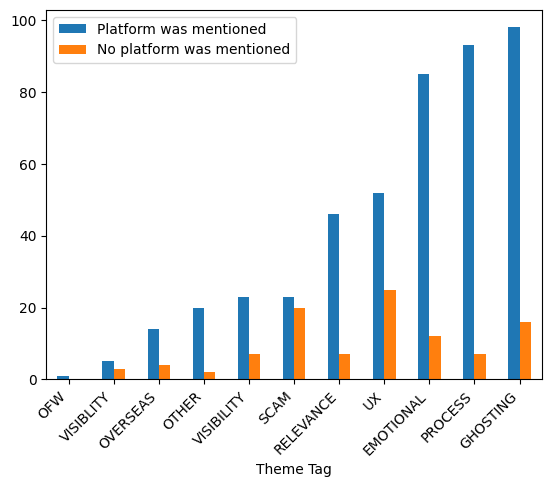

In [133]:
final_df['Has Platform'] = final_df['Platform Mentioned'].notna()

grouped = (
    final_df
    .groupby(['Theme Tag', 'Has Platform'])
    .size()
    .unstack(fill_value=0)
)

grouped.columns = ['Platform was mentioned', 'No platform was mentioned']

# sort by total counts per theme
grouped = grouped.loc[grouped.sum(axis=1).sort_values().index]

grouped.plot(kind='bar')
plt.gca().set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha='right')

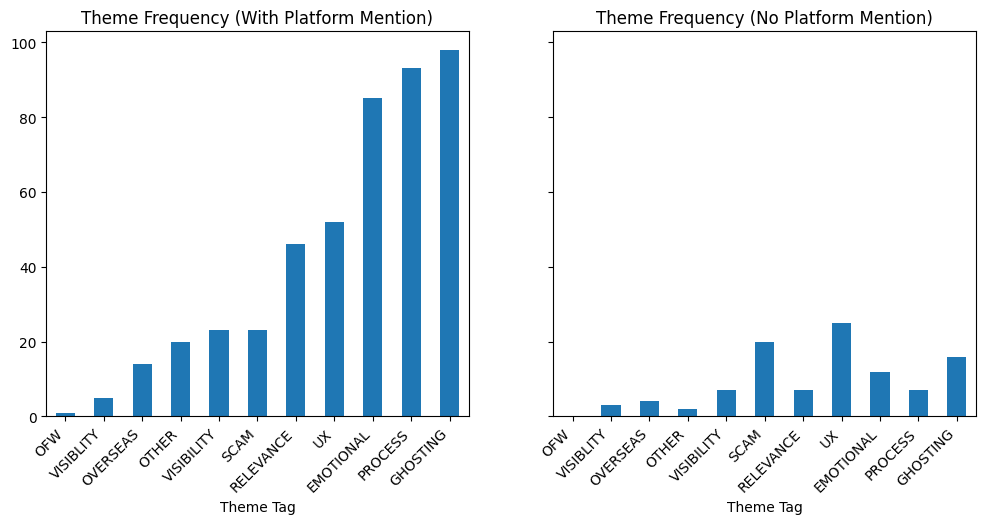

In [143]:
fig, axs = plt.subplots(1, 2, figsize = (12, 5), sharey=True)
grouped['No platform was mentioned'].plot(ax=axs[1], kind='bar', rot=45)
grouped['Platform was mentioned'].plot(ax=axs[0], kind='bar', rot=45)
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha='right')
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha='right')
axs[1].set_title("Theme Frequency (No Platform Mention)")
axs[0].set_title("Theme Frequency (With Platform Mention)")
plt.show()

In [127]:
axs

array([<Axes: xlabel='Theme Tag'>, <Axes: xlabel='Theme Tag'>],
      dtype=object)